Predictive Inventory Management and Logistics Optimization

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [67]:
df = pd.read_csv("./data/inventory_dataset.csv")
df.head()

,Warehouse,Product,Supplier,Stock_Level,Reorder_Level,Transport_Cost,Last_Updated
0,WH-B,Mouse,Supplier-Y,349.0,49,1543.04,2025-06-16
1,WH-A,Camera,Supplier-A,171.0,102,1440.89,2026-05-25
2,WH-D,Printer,Supplier-X,403.0,85,1907.78,2024-07-03
3,WH-B,Mouse,Supplier-A,NaN,94,1278.95,2025-05-24
4,WH-E,Printer,Supplier-Y,369.0,21,1757.49,2025-05-12


In [68]:
total_null_values = df.isnull().sum()
print(f"Total null values in the dataset: {total_null_values}")

Total null values in the dataset: Warehouse           0
Product             0
Supplier            0
Stock_Level       200
Reorder_Level       0
Transport_Cost      0
Last_Updated        0
dtype: int64


In [69]:
duplicate_values = df.duplicated().sum()
print(f"Total duplicate values in the dataset: {duplicate_values}")

Total duplicate values in the dataset: 0


In [70]:
distinct_values = df.nunique()
print(f"Total distinct values in the dataset: \n{distinct_values}")

Total distinct values in the dataset: 
Warehouse           5
Product            10
Supplier            5
Stock_Level       398
Reorder_Level     189
Transport_Cost    995
Last_Updated      531
dtype: int64


In [71]:
warehouse_counts = df["Warehouse"].value_counts()
product_counts = df["Product"].value_counts()
print(f"Warehouse counts:\n {warehouse_counts}")
print(f"Product counts: \n {product_counts}")


Warehouse counts:
 Warehouse
WH-D    224
WH-B    199
WH-C    196
WH-A    192
WH-E    189
Name: count, dtype: int64
Product counts: 
 Product
Camera      117
Keyboard    107
CPU         104
Laptop      104
Monitor     102
Speaker     100
Printer      93
Tablet       92
Mobile       91
Mouse        90
Name: count, dtype: int64


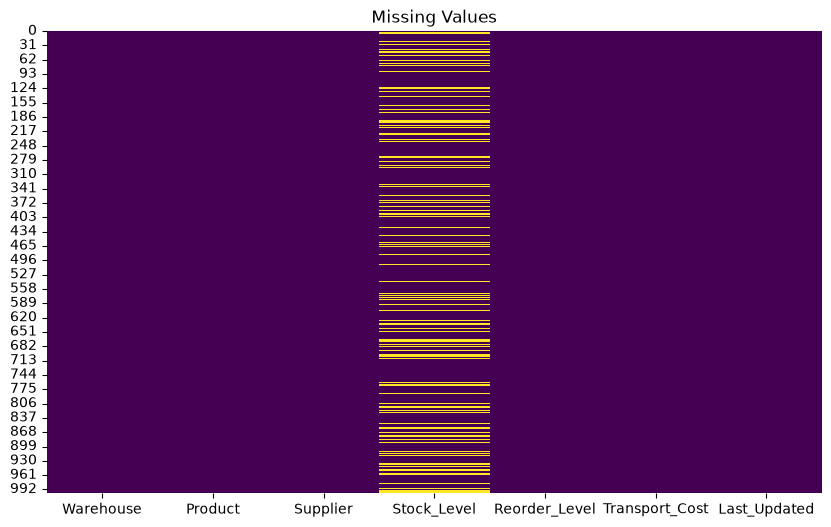

In [72]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values")
plt.show()

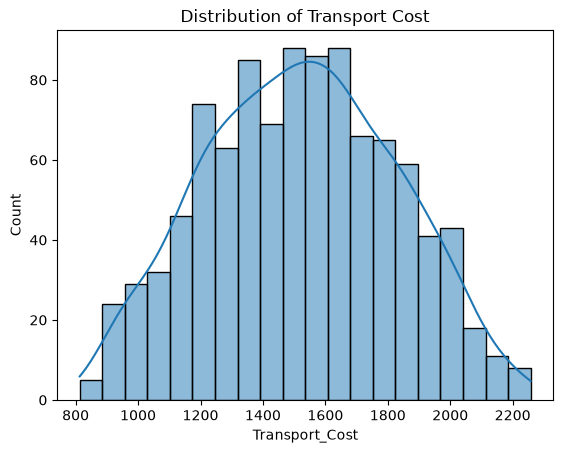

In [73]:
sns.histplot(df['Transport_Cost'], bins=20, kde = True)
plt.title("Distribution of Transport Cost")
plt.show()

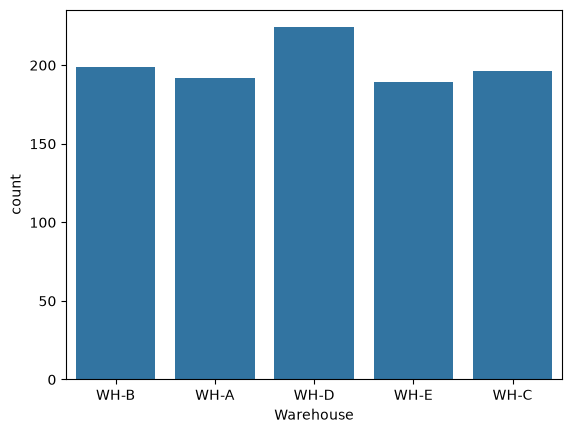

In [74]:
sns.countplot(x="Warehouse", data=df)
plt.show()

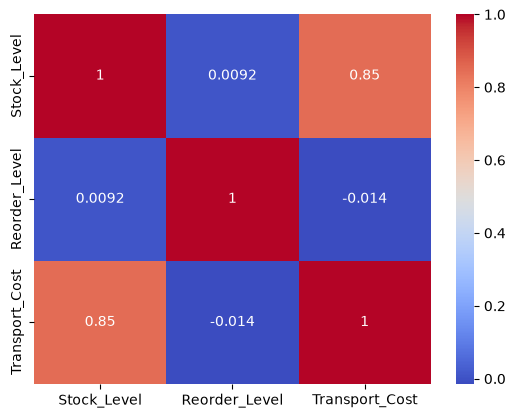

In [75]:
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm")
plt.show()

DATA CLEANING--

In [76]:
clean_df = df.copy()

In [77]:

clean_df.drop_duplicates(inplace=True)
clean_df.isnull().sum()

Warehouse           0
Product             0
Supplier            0
Stock_Level       200
Reorder_Level       0
Transport_Cost      0
Last_Updated        0
dtype: int64

In [78]:
clean_df["Stock_Level"] = clean_df["Stock_Level"].fillna(clean_df["Stock_Level"].median())

In [79]:
null_removed = clean_df.isnull().sum()
print(f"Data after filling missing values: \n {null_removed}")

Data after filling missing values: 
 Warehouse         0
Product           0
Supplier          0
Stock_Level       0
Reorder_Level     0
Transport_Cost    0
Last_Updated      0
dtype: int64


In [80]:
clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Warehouse       1000 non-null   str    
 1   Product         1000 non-null   str    
 2   Supplier        1000 non-null   str    
 3   Stock_Level     1000 non-null   float64
 4   Reorder_Level   1000 non-null   int64  
 5   Transport_Cost  1000 non-null   float64
 6   Last_Updated    1000 non-null   str    
dtypes: float64(2), int64(1), str(4)
memory usage: 84.2 KB


FEATURE ENGINEERING--

In [81]:
feature_df = clean_df.copy()

In [82]:
# feature_df.dtypes
feature_df["Last_Updated"] = pd.to_datetime(
    feature_df["Last_Updated"]
)
# feature_df.dtypes

In [83]:
feature_df["Year"] = feature_df["Last_Updated"].dt.year 
feature_df["Month"] = feature_df["Last_Updated"].dt.month
feature_df["Day"] = feature_df["Last_Updated"].dt.day
feature_df["Weekday"] = feature_df["Last_Updated"].dt.weekday

In [84]:
# feature_df

In [85]:
feature_df["Stock_Shortage_Risk"] = (
    feature_df["Stock_Level"] < feature_df["Reorder_Level"]
).astype(int)

In [86]:
feature_df[["Stock_Level", "Reorder_Level", "Stock_Shortage_Risk"]].head()

,Stock_Level,Reorder_Level,Stock_Shortage_Risk
0,349.0,49,0
1,171.0,102,0
2,403.0,85,0
3,242.5,94,0
4,369.0,21,0


In [87]:
feature_df["Stock_Shortage_Risk"].value_counts()

Stock_Shortage_Risk
0    814
1    186
Name: count, dtype: int64

In [88]:
feature_df["Stock_Shortage_Risk"].value_counts(normalize=True)*100

Stock_Shortage_Risk
0    81.4
1    18.6
Name: proportion, dtype: float64

In [89]:
categorical_columns = [
    "Warehouse",
    "Product",
    "Supplier"
]

df_encoded = pd.get_dummies(
    feature_df,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

In [90]:
# df_encoded.head()
df_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Stock_Level          1000 non-null   float64       
 1   Reorder_Level        1000 non-null   int64         
 2   Transport_Cost       1000 non-null   float64       
 3   Last_Updated         1000 non-null   datetime64[us]
 4   Year                 1000 non-null   int32         
 5   Month                1000 non-null   int32         
 6   Day                  1000 non-null   int32         
 7   Weekday              1000 non-null   int32         
 8   Stock_Shortage_Risk  1000 non-null   int64         
 9   Warehouse_WH-B       1000 non-null   int64         
 10  Warehouse_WH-C       1000 non-null   int64         
 11  Warehouse_WH-D       1000 non-null   int64         
 12  Warehouse_WH-E       1000 non-null   int64         
 13  Product_Camera       1000 non-null   int64   

In [91]:
df_encoded.head()
df_encoded = df_encoded.drop("Last_Updated", axis=1)

ML Models 

In [92]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

import matplotlib.pyplot as plt



In [93]:
X = df_encoded.drop(
    ["Transport_Cost", "Stock_Shortage_Risk"],
    axis=1
)

y = df_encoded["Transport_Cost"]

In [94]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Training Random Forest Regressor

In [95]:
regressor = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

regressor.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [96]:
y_pred = regressor.predict(X_test)
y_pred

array([1108.8376 , 1141.56915, 1272.14295,  933.61545, 1417.91605,
       1158.46965, 1552.372  , 1674.18045, 1259.62025, 1652.43145,
       1681.7379 , 1258.0899 , 1745.5766 , 1204.797  , 1469.36625,
       1805.721  , 1519.89   , 1842.7601 , 1586.5934 , 1456.95935,
       1581.70635, 1802.5622 , 1454.52585, 1308.96265, 1598.8628 ,
       1684.3501 , 1429.12595, 1593.2017 , 1415.7339 , 1885.09165,
       1398.5904 , 2037.9454 , 1921.2013 , 1750.3524 , 1307.29365,
       1532.3396 , 1043.71365, 1662.1691 , 1014.00905, 1300.7101 ,
       2052.7359 , 2132.82645, 1847.16045, 1761.69475, 1496.0381 ,
       1420.7823 , 1743.4062 , 1506.95435, 1606.5076 , 1428.8178 ,
       1297.1209 , 1525.7027 , 1124.1899 , 1414.39905, 1920.9109 ,
       1904.3105 , 1535.4661 , 1032.85335, 1435.41425, 1485.325  ,
       1946.5874 , 1953.6584 , 1414.23015, 1682.7386 , 1233.79015,
        958.5033 , 1965.942  , 1545.24875, 1271.4529 , 1515.13835,
       1887.21565, 1804.99495, 1343.45265, 1414.5458 , 1188.19

Evaluation

In [97]:
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score :", r2_score(y_test, y_pred))

MAE : 92.69724575000015
MSE : 19234.185481306547
RMSE : 138.68736597580383
R2 Score : 0.7697009209841557


Classification : Stock Shortage Risk

In [98]:
from sklearn.linear_model import LogisticRegression

In [99]:
x_cls=df_encoded.drop(
  ['Stock_Shortage_Risk','Transport_Cost']
  ,axis=1
)

y_cls=df_encoded['Stock_Shortage_Risk']

In [100]:
x_train_cls,x_test_cls,y_train_cls,y_test_cls=train_test_split(
  x_cls,y_cls,random_state=42,test_size=0.2
)

In [101]:
model=LogisticRegression()
model.fit(
    
  x_train_cls,
  y_train_cls
)

c:\Users\Asus\anaconda3\envs\pyspark311\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [102]:
y_prediction=model.predict(x_test_cls)
print(y_prediction)

[1 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1
 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 0
 1 1 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 1 1 0 0 1
 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 1 1 1 0 1 0 1 0 1 1 0 0 0 0 0 1
 0 0 0 0 0 1 0 1 0 1 0 0 0 0 0]


In [103]:
from sklearn.metrics import r2_score , accuracy_score , f1_score , precision_score  , recall_score 

print("Accuracy :", accuracy_score(y_test_cls, y_prediction))

print("Precision :", precision_score(y_test_cls, y_prediction))

print("Recall :", recall_score(y_test_cls, y_prediction))

print("F1 :", f1_score(y_test_cls, y_prediction))

print("R2 Score :", r2_score(y_test_cls,y_prediction))

Accuracy : 1.0
Precision : 1.0
Recall : 1.0
F1 : 1.0
R2 Score : 1.0
